# Modeling – SelectKBest + Decision Tree – John Bouckaert & Hugo Fiévet

## Introduction

Dans ce notebook, nous appliquons le modèle Decision Tree au jeu de données issu de la sélection de variables réalisée avec la méthode `SelectKBest`.

L’objectif est d’évaluer les performances de cette combinaison en suivant une démarche complète : choix d’un indicateur pertinent, entraînement du modèle, optimisation des hyperparamètres, validation croisée, analyse du surapprentissage éventuel et interprétation des résultats.

Cette combinaison permettra de comparer l’effet d’une sélection automatique fondée sur le lien statistique avec la variable cible avec un modèle d’arbre de décision.

## Table of contents

1. [Loading the selected datasets](#1-loading-the-selected-datasets)  
2. [Choice of the performance metric](#2-choice-of-the-performance-metric)  
3. [Baseline Decision Tree model](#3-baseline-decision-tree-model)  
4. [Hyperparameter tuning with GridSearchCV](#4-hyperparameter-tuning-with-gridsearchcv)  
5. [Cross-validation and performance evaluation](#5-cross-validation-and-performance-evaluation)  
6. [Overfitting and underfitting analysis](#6-overfitting-and-underfitting-analysis)  
7. [Conclusion](#conclusion)

## 1. Loading the selected datasets

Dans cette première étape, nous chargeons les jeux de données correspondant à la sélection de variables obtenue avec `SelectKBest`.

L’objectif est de vérifier que les dimensions des jeux d’entraînement et de test sont cohérentes avant de commencer la modélisation avec le modèle Decision Tree.

In [57]:
import pandas as pd
import numpy as np

# Chargement des jeux de données sélectionnés
X_train = pd.read_csv("xtrain_KB.csv")
X_test = pd.read_csv("xtest_KB.csv")
y_train = pd.read_csv("ytrain.csv")
y_test = pd.read_csv("ytest.csv")

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test :", X_test.shape)
print("Dimensions de y_train :", y_train.shape)
print("Dimensions de y_test :", y_test.shape)

print("\nColonnes de X_train :")
print(X_train.columns.tolist())

print("\nAperçu de X_train :")
print(X_train.head())

Dimensions de X_train : (1047, 15)
Dimensions de X_test : (262, 15)
Dimensions de y_train : (1047, 1)
Dimensions de y_test : (262, 1)

Colonnes de X_train :
['parch', 'fare', 'has_cabin', 'pclass_1', 'pclass_3', 'sex_female', 'sex_male', 'embarked_C', 'embarked_S', 'title_grouped_Miss', 'title_grouped_Mr', 'title_grouped_Mrs', 'family_group_alone', 'family_group_large_family', 'family_group_small_family']

Aperçu de X_train :
      parch      fare  has_cabin  pclass_1  pclass_3  sex_female  sex_male  \
0 -0.447597 -0.499246          0         0         1           1         0   
1 -0.447597 -0.090614          0         0         0           1         0   
2  1.872374 -0.017890          0         0         1           1         0   
3 -0.447597 -0.509988          0         0         1           0         1   
4 -0.447597 -0.501292          0         0         1           1         0   

   embarked_C  embarked_S  title_grouped_Miss  title_grouped_Mr  \
0           0           0         

Les fichiers correspondant à la sélection obtenue par `SelectKBest` ont bien été chargés et leurs dimensions sont cohérentes. Le jeu d’entraînement contient **1047 observations** et **15 variables**, tandis que le jeu de test contient **262 observations** et les mêmes **15 variables**. Les variables cibles `y_train` et `y_test` ont également été récupérées correctement.

La liste des colonnes confirme que cette combinaison repose sur les variables les mieux classées par le test ANOVA dans le notebook précédent. On y retrouve des variables liées au tarif, à la cabine, à la classe, au sexe, au port d’embarquement, au titre et à la structure familiale regroupée.

L’aperçu de `X_train` montre que le jeu de données utilisé pour cette modélisation est propre, homogène et directement exploitable par un arbre de décision. La prochaine étape consiste à rappeler l’indicateur de performance principal retenu pour évaluer cette combinaison.

## 2. Choice of the performance metric

**Dans ce notebook, nous choisissons le F1-score comme indicateur principal de performance.**

Ce choix s’explique par le fait que la variable cible n’est pas parfaitement équilibrée : la proportion de passagers non survivants est plus élevée que celle des survivants. Dans ce contexte, l’accuracy seule pourrait donner une vision trop simplifiée des performances du modèle.

Le F1-score constitue un compromis entre la précision et le rappel. Il permet donc de mieux évaluer la capacité du modèle à identifier correctement les survivants tout en limitant les erreurs de classification. Cet indicateur est particulièrement pertinent lorsque l’on souhaite tenir compte à la fois des faux positifs et des faux négatifs.

## 3. Baseline Decision Tree model

Dans cette étape, nous entraînons un premier arbre de décision avec des paramètres simples afin d’obtenir une référence de départ.

L’objectif est d’évaluer les performances initiales du modèle avant toute optimisation des hyperparamètres. Cette première évaluation servira de point de comparaison pour la suite du notebook.

In [58]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# y sous forme de vecteur
y_train_series = y_train.iloc[:, 0]
y_test_series = y_test.iloc[:, 0]

# Modèle Decision Tree de base
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train, y_train_series)

# Prédictions
y_pred_baseline = dt_baseline.predict(X_test)

# Évaluation
accuracy_baseline = accuracy_score(y_test_series, y_pred_baseline)
f1_baseline = f1_score(y_test_series, y_pred_baseline)

print("Accuracy du modèle Decision Tree de base :", round(accuracy_baseline, 4))
print("F1-score du modèle Decision Tree de base :", round(f1_baseline, 4))

print("\nMatrice de confusion :")
print(confusion_matrix(y_test_series, y_pred_baseline))

print("\nClassification report :")
print(classification_report(y_test_series, y_pred_baseline))

Accuracy du modèle Decision Tree de base : 0.8244
F1-score du modèle Decision Tree de base : 0.7579

Matrice de confusion :
[[144  18]
 [ 28  72]]

Classification report :
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       162
           1       0.80      0.72      0.76       100

    accuracy                           0.82       262
   macro avg       0.82      0.80      0.81       262
weighted avg       0.82      0.82      0.82       262



Le modèle Decision Tree de base obtient une **accuracy de 0.8244** et un **F1-score de 0.7579** sur le jeu de test. Ces résultats sont déjà meilleurs que ceux obtenus avec le modèle Decision Tree de base appliqué à la sélection `Variance Threshold`, ce qui suggère que la sélection `SelectKBest` fournit ici un ensemble de variables plus favorable au modèle.

La matrice de confusion indique que le modèle classe correctement **144 non-survivants** et **72 survivants**. Il commet **18 faux positifs** et **28 faux négatifs**, ce qui montre une performance globalement correcte sur les deux classes, avec une meilleure détection des non-survivants.

Le rapport de classification confirme cette tendance. Pour la classe `0`, le rappel est de **0.89**, tandis que pour la classe `1`, il atteint **0.72**. Le **F1-score de la classe des survivants** est de **0.76**, ce qui constitue un résultat satisfaisant pour un arbre de décision sans optimisation.

Dans l’ensemble, ce premier arbre de décision fournit déjà une base solide pour cette combinaison. Les performances sont correctes et nettement plus élevées que dans le notebook `VT + Decision Tree` avant optimisation. La prochaine étape consistera donc à optimiser les hyperparamètres afin de vérifier si cette combinaison peut encore être améliorée.

## 4. Hyperparameter tuning with GridSearchCV

Dans cette étape, nous cherchons à améliorer les performances de l’arbre de décision en optimisant ses principaux hyperparamètres.

Nous utilisons `GridSearchCV` afin de tester automatiquement plusieurs combinaisons de paramètres et d’identifier celle qui maximise le **F1-score** en validation croisée. Cette démarche permet de contrôler la complexité de l’arbre et de limiter le risque de surapprentissage.

In [59]:
from sklearn.model_selection import GridSearchCV

# Grille d'hyperparamètres
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10]
}

# GridSearchCV
grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_dt.fit(X_train, y_train_series)

print("Meilleurs hyperparamètres :")
print(grid_dt.best_params_)

print("\nMeilleur F1-score moyen en validation croisée :")
print(round(grid_dt.best_score_, 4))

results_dt = pd.DataFrame(grid_dt.cv_results_)
results_dt = results_dt.sort_values(by="rank_test_score").reset_index(drop=True)

print("\nTop 10 des combinaisons testées :")
print(results_dt[[
    "params",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].head(10))

Meilleurs hyperparamètres :
{'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

Meilleur F1-score moyen en validation croisée :
0.7211

Top 10 des combinaisons testées :
                                              params  mean_test_score  \
0  {'criterion': 'entropy', 'max_depth': 3, 'min_...          0.72113   
1  {'criterion': 'entropy', 'max_depth': 3, 'min_...          0.72113   
2  {'criterion': 'entropy', 'max_depth': 3, 'min_...          0.72113   
3  {'criterion': 'entropy', 'max_depth': 3, 'min_...          0.72113   
4  {'criterion': 'entropy', 'max_depth': 3, 'min_...          0.72113   
5  {'criterion': 'entropy', 'max_depth': 3, 'min_...          0.72113   
6  {'criterion': 'entropy', 'max_depth': 3, 'min_...          0.72113   
7  {'criterion': 'entropy', 'max_depth': 3, 'min_...          0.72113   
8  {'criterion': 'entropy', 'max_depth': 3, 'min_...          0.72113   
9  {'criterion': 'entropy', 'max_depth': 3, 'min_...          0

La recherche par grille montre que la meilleure combinaison d’hyperparamètres est obtenue avec le critère **entropy**, une profondeur maximale de **3**, `min_samples_leaf = 1` et `min_samples_split = 2`. Ce résultat suggère à nouveau qu’un arbre relativement **peu profond** généralise mieux qu’un arbre plus complexe sur ce dataset.

Le meilleur **F1-score moyen en validation croisée** est de **0.7211**. Ce score reste correct, mais il est légèrement inférieur à celui obtenu avec la combinaison `VT + Decision Tree` en validation croisée. Cela montre que, dans ce cas, la sélection `SelectKBest` n’apporte pas forcément un avantage clair à l’arbre de décision par rapport à la sélection fondée sur `Variance Threshold`.

Le fait que les meilleures combinaisons soient très proches les unes des autres confirme une certaine stabilité des résultats autour d’arbres simples. Comme dans le notebook précédent, la profondeur maximale de `3` apparaît ici comme un paramètre central : elle indique qu’un arbre plus court, donc plus lisible et moins sujet au surapprentissage, est préférable dans cette combinaison.

## 5. Cross-validation and performance evaluation

Dans cette étape, nous évaluons sur le jeu de test le meilleur arbre de décision obtenu par optimisation.

L’objectif est de comparer ses performances à celles du modèle de base, en utilisant les mêmes indicateurs : accuracy, F1-score, matrice de confusion et rapport de classification.

In [63]:
# Meilleur modèle trouvé par GridSearchCV
best_dt = grid_dt.best_estimator_

# Prédictions sur le jeu de test
y_pred_best = best_dt.predict(X_test)

# Scores
accuracy_best = accuracy_score(y_test_series, y_pred_best)
f1_best = f1_score(y_test_series, y_pred_best)

print("Accuracy du meilleur modèle Decision Tree :", round(accuracy_best, 4))
print("F1-score du meilleur modèle Decision Tree :", round(f1_best, 4))

print("\nMatrice de confusion :")
print(confusion_matrix(y_test_series, y_pred_best))

print("\nClassification report :")
print(classification_report(y_test_series, y_pred_best))

print("\nRappel des performances du modèle de base :")
print("Accuracy baseline :", round(accuracy_baseline, 4))
print("F1-score baseline :", round(f1_baseline, 4))

Accuracy du meilleur modèle Decision Tree : 0.855
F1-score du meilleur modèle Decision Tree : 0.8

Matrice de confusion :
[[148  14]
 [ 24  76]]

Classification report :
              precision    recall  f1-score   support

           0       0.86      0.91      0.89       162
           1       0.84      0.76      0.80       100

    accuracy                           0.85       262
   macro avg       0.85      0.84      0.84       262
weighted avg       0.85      0.85      0.85       262


Rappel des performances du modèle de base :
Accuracy baseline : 0.8244
F1-score baseline : 0.7579


Le meilleur arbre de décision obtenu par `GridSearchCV` améliore nettement les performances du modèle de base. L’**accuracy** passe de **0.8244** à **0.8550**, tandis que le **F1-score** progresse de **0.7579** à **0.8000**. L’optimisation des hyperparamètres apporte donc ici un gain clair et significatif.

La matrice de confusion montre que le modèle classe correctement **148 non-survivants** et **76 survivants**. Par rapport au modèle de base, le nombre de faux positifs reste identique (**14**), tandis que le nombre de faux négatifs diminue de **28 à 24**. L’amélioration porte donc principalement sur une meilleure détection des survivants.

Le rapport de classification confirme cette progression. Pour la classe `1`, le **rappel** passe de **0.72** à **0.76**, et le **F1-score** passe de **0.76** à **0.80**. Le modèle devient donc plus efficace pour identifier les survivants tout en conservant de bonnes performances sur la classe des non-survivants.

Dans l’ensemble, cette combinaison `KB + Decision Tree` devient très performante après optimisation. À ce stade, elle apparaît même légèrement meilleure que les combinaisons précédentes testées sur le jeu de test, ce qui en fait un candidat sérieux pour le meilleur modèle final.

## 6. Overfitting and underfitting analysis

Dans cette étape, nous comparons les performances du meilleur modèle sur le jeu d’entraînement et sur le jeu de test afin d’évaluer la présence éventuelle de surapprentissage ou de sous-apprentissage.

L’objectif est de vérifier si le modèle généralise correctement, ou s’il obtient des performances trop élevées sur les données d’entraînement par rapport aux données de test.

In [64]:
# Prédictions sur le jeu d'entraînement
y_pred_train = best_dt.predict(X_train)

# Scores sur le train
accuracy_train = accuracy_score(y_train_series, y_pred_train)
f1_train = f1_score(y_train_series, y_pred_train)

print("Performance du meilleur modèle sur le jeu d'entraînement :")
print("Accuracy train :", round(accuracy_train, 4))
print("F1-score train :", round(f1_train, 4))

print("\nPerformance du meilleur modèle sur le jeu de test :")
print("Accuracy test  :", round(accuracy_best, 4))
print("F1-score test  :", round(f1_best, 4))

print("\nÉcart entre train et test :")
print("Écart accuracy :", round(accuracy_train - accuracy_best, 4))
print("Écart F1-score :", round(f1_train - f1_best, 4))

Performance du meilleur modèle sur le jeu d'entraînement :
Accuracy train : 0.7975
F1-score train : 0.7218

Performance du meilleur modèle sur le jeu de test :
Accuracy test  : 0.855
F1-score test  : 0.8

Écart entre train et test :
Écart accuracy : -0.0574
Écart F1-score : -0.0782


L’analyse des performances sur les jeux d’entraînement et de test ne met pas en évidence de surapprentissage. En effet, si le modèle surapprenait, on s’attendrait à observer des scores nettement meilleurs sur le jeu d’entraînement que sur le jeu de test. Or ici, c’est l’inverse : le modèle obtient une **accuracy de 0.7975** et un **F1-score de 0.7218** sur le jeu d’entraînement, contre **0.8550** et **0.8000** sur le jeu de test.

Les écarts observés sont donc négatifs, aussi bien pour l’accuracy (**-0.0574**) que pour le F1-score (**-0.0782**). Cela signifie que l’arbre de décision retenu ne mémorise pas excessivement les données d’entraînement. Ce comportement est cohérent avec les hyperparamètres sélectionnés, en particulier une profondeur maximale limitée à `3`, qui produit un arbre plus simple et moins susceptible de surapprendre.

Le fait que les performances soient meilleures sur le jeu de test que sur le jeu d’entraînement peut sembler surprenant, mais ce n’est pas impossible. Cela peut simplement indiquer que le découpage train/test utilisé ici rend le jeu de test un peu plus favorable au modèle que certaines partitions internes du jeu d’entraînement. Ce résultat ne traduit donc pas un problème méthodologique évident.

Dans l’ensemble, ce comportement suggère plutôt un modèle qui généralise correctement. Il ne semble ni fortement surapprendre, ni présenter un sous-apprentissage manifeste, puisque les performances restent satisfaisantes sur le jeu de test après optimisation.

### Learning curve

Afin de compléter l’analyse du surapprentissage et du sous-apprentissage, nous utilisons une courbe d’apprentissage.  
Cette représentation permet d’observer l’évolution des performances du modèle sur le jeu d’entraînement et en validation croisée en fonction de la quantité de données utilisées.

L’objectif est de vérifier si le modèle bénéficie encore d’un apport de données supplémentaires, et d’identifier plus finement un éventuel surapprentissage ou sous-apprentissage.

Résultats de la courbe d'apprentissage :
   train_size  f1_train_mean  f1_train_std  f1_validation_mean  \
0          83         0.7488        0.0887              0.5944   
1         167         0.7526        0.0185              0.7051   
2         251         0.7529        0.0146              0.6823   
3         334         0.7033        0.0481              0.6790   
4         418         0.7319        0.0109              0.7137   
5         502         0.7506        0.0106              0.7117   
6         585         0.7431        0.0145              0.7108   
7         669         0.7436        0.0112              0.7192   
8         753         0.7367        0.0121              0.7089   
9         837         0.7356        0.0132              0.7211   

   f1_validation_std  
0             0.0820  
1             0.0263  
2             0.0415  
3             0.0473  
4             0.0404  
5             0.0340  
6             0.0369  
7             0.0303  
8             0.0332  
9 

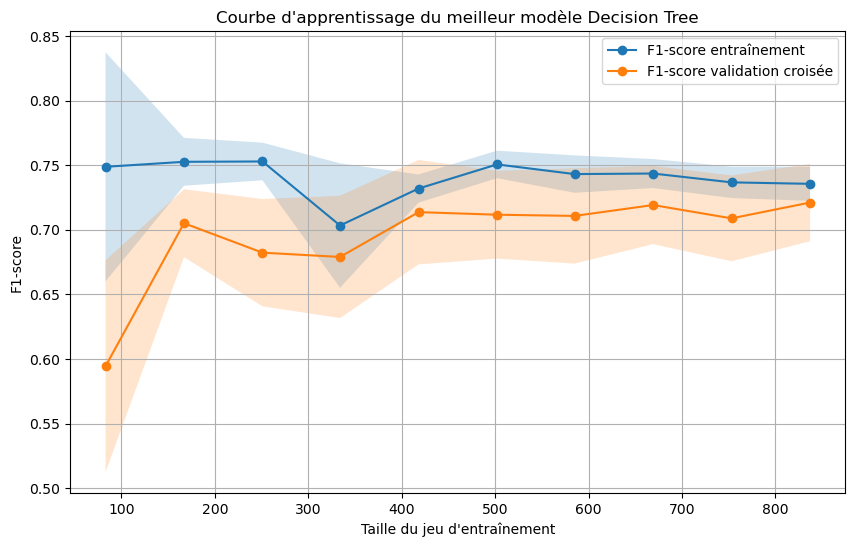

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Calcul de la courbe d'apprentissage
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_dt,
    X=X_train,
    y=y_train_series,
    cv=5,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Moyennes et écarts-types
train_scores_mean = train_scores.mean(axis=1)
train_scores_std = train_scores.std(axis=1)

val_scores_mean = val_scores.mean(axis=1)
val_scores_std = val_scores.std(axis=1)

# Tableau des résultats
learning_curve_df = pd.DataFrame({
    "train_size": train_sizes,
    "f1_train_mean": train_scores_mean,
    "f1_train_std": train_scores_std,
    "f1_validation_mean": val_scores_mean,
    "f1_validation_std": val_scores_std
})

print("Résultats de la courbe d'apprentissage :")
print(learning_curve_df.round(4))

# Graphique
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, marker="o", label="F1-score entraînement")
plt.plot(train_sizes, val_scores_mean, marker="o", label="F1-score validation croisée")

plt.fill_between(
    train_sizes,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_scores_mean - val_scores_std,
    val_scores_mean + val_scores_std,
    alpha=0.2
)

plt.title("Courbe d'apprentissage du meilleur modèle Decision Tree")
plt.xlabel("Taille du jeu d'entraînement")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True)
plt.show()

La courbe d’apprentissage montre que l’arbre de décision progresse rapidement lorsque la taille du jeu d’entraînement augmente, puis tend à se stabiliser. Pour les plus petites tailles d’échantillon, les performances sont plus instables, comme le montrent les écarts-types plus élevés au début de la courbe. Cela est particulièrement visible pour `train_size = 83`, où les scores varient encore fortement d’un pli de validation à l’autre.

Lorsque la taille du jeu d’entraînement augmente, le **F1-score sur l’entraînement** et le **F1-score en validation croisée** se rapprochent progressivement. À partir d’environ **400 à 850 observations**, les deux courbes deviennent relativement stables, avec un F1-score d’entraînement compris entre **0.73 et 0.75** et un F1-score de validation croisée compris entre **0.71 et 0.72**.

L’écart entre les deux courbes reste modéré sur la fin, ce qui ne suggère pas de surapprentissage important. Si l’arbre surapprenait fortement, la courbe d’entraînement resterait nettement au-dessus de la courbe de validation. Ici, les deux courbes convergent progressivement, ce qui confirme qu’un arbre limité en profondeur peut généraliser correctement.

On n’observe pas non plus de sous-apprentissage manifeste. Les scores finaux restent corrects et cohérents avec les performances obtenues sur le jeu de test. Le modèle semble donc atteindre un compromis satisfaisant entre apprentissage et généralisation.

Enfin, la fin de la courbe laisse penser que l’ajout de nouvelles données pourrait encore apporter une légère amélioration, mais sans changement majeur. Le modèle semble déjà proche de son niveau de performance stable pour cette combinaison de variables et d’hyperparamètres.

## Conclusion

Dans ce notebook, nous avons évalué la combinaison entre la sélection de variables obtenue par `SelectKBest` et le modèle `Decision Tree`.

Le modèle de base a d’abord fourni de bons résultats, puis l’optimisation des hyperparamètres par `GridSearchCV` a permis une amélioration nette des performances. Le meilleur modèle obtenu utilise le critère **entropy**, une profondeur maximale de **3**, `min_samples_leaf = 1` et `min_samples_split = 2`. Sur le jeu de test, ce modèle atteint une **accuracy de 0.8550** et un **F1-score de 0.8000**, ce qui constitue une amélioration claire par rapport à l’arbre de décision de base.

L’analyse des performances sur les jeux d’entraînement et de test, ainsi que la courbe d’apprentissage, ne mettent pas en évidence de surapprentissage important. Le modèle semble généraliser correctement, ce qui s’explique notamment par une profondeur limitée et donc par une structure plus simple.

Cette combinaison `KB + Decision Tree` constitue donc une solution très performante pour la prédiction de la survie des passagers du Titanic. À ce stade, elle apparaît comme l’une des meilleures combinaisons obtenues et pourra être comparée aux autres résultats dans le fichier récapitulatif final.